In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import geopandas as gpd
from shapely import Polygon
import ee, geemap
import geemap.colormaps as cm

In [2]:
from hsa.compute import make_local_dask_client
client = make_local_dask_client(n_workers=10,
                                threads_per_worker=1,
                                memory_limit="10GiB",
                                local_directory='dask-tmp')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 10
Total threads: 10,Total memory: 100.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35567,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39685,Total threads: 1
Dashboard: http://127.0.0.1:46385/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:38447,


In [3]:
from hsa.movement.geometry import prepare_trajectory_data
df = pd.read_csv("data/reloc.csv")
reloc = prepare_trajectory_data(df[["ID", "Timestamp", "geometry"]],
                                id_col = "ID",
                                geometry_col="geometry",
                                source_crs = "EPSG:32733",
                                target_crs = "EPSG:32733")

/tmp/ipykernel_1794719/2980260245.py:2: DtypeWarning: Columns (0: DataType, 1: LoggerDate, 2: LoggerTime, 3: DataSource1, 4: DataSource2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/reloc.csv")


In [4]:
from hsa.compute import open_raster_stack_zarr
from hsa.compute import suggest_xy_chunks
import xarray as xr

env = open_raster_stack_zarr("lion_predictor_stack_big.zarr")
env = env.chunk(suggest_xy_chunks(env, target_chunk_mb=256))

In [5]:
from hsa.sampling import get_availability_domain, sample_available_points, sample_raster_stack
domains = get_availability_domain(reloc, id_col="ID")
sampling = sample_available_points(domains, used = reloc, n_per_used = 10, id_col = "ID")
sampled = sample_raster_stack(sampling, env, id_cols="ID")

/home/molzoo/miniforge3/envs/hsa/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 28.27 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


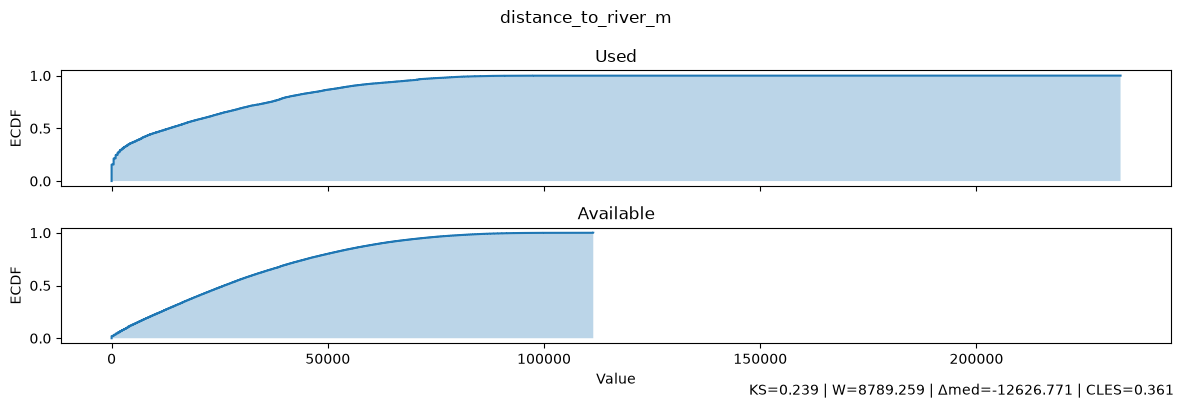

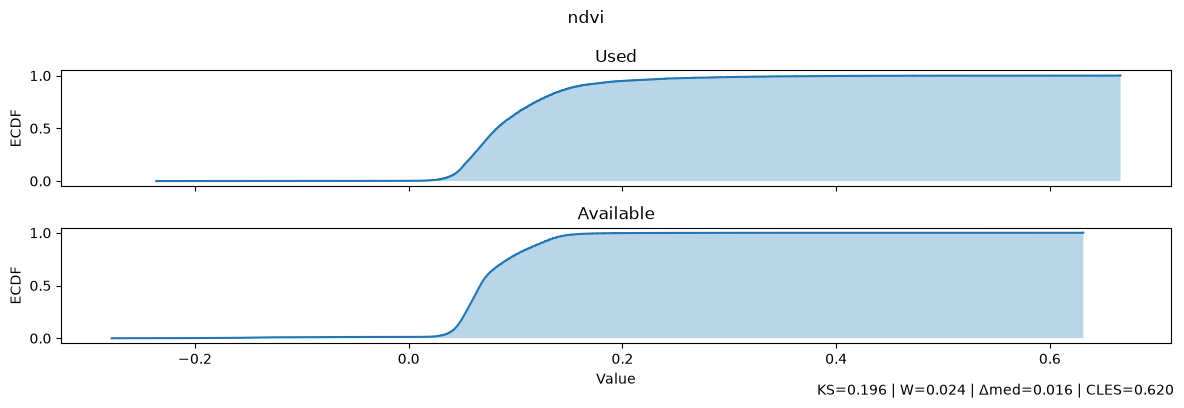

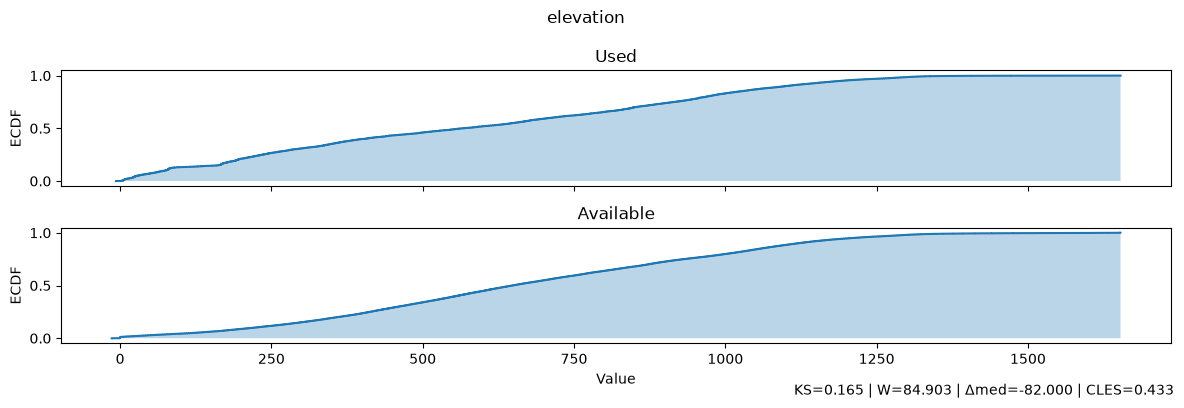

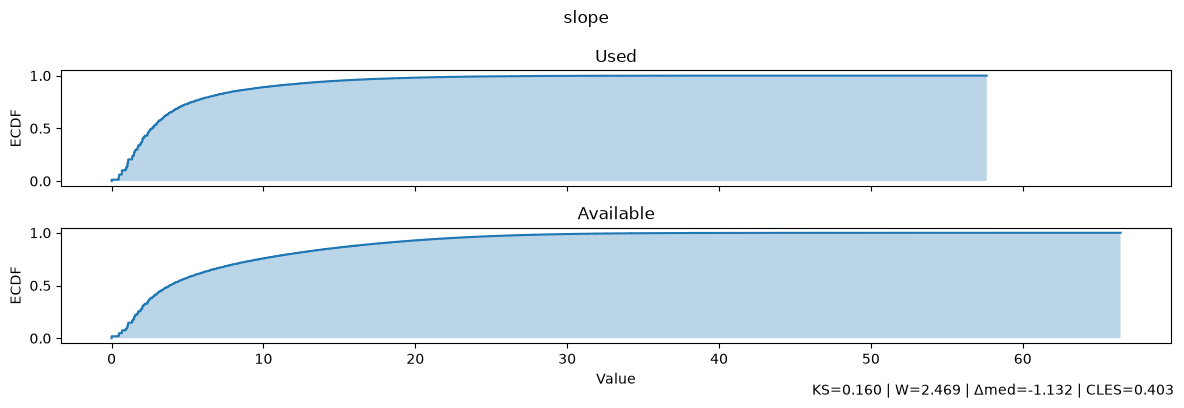

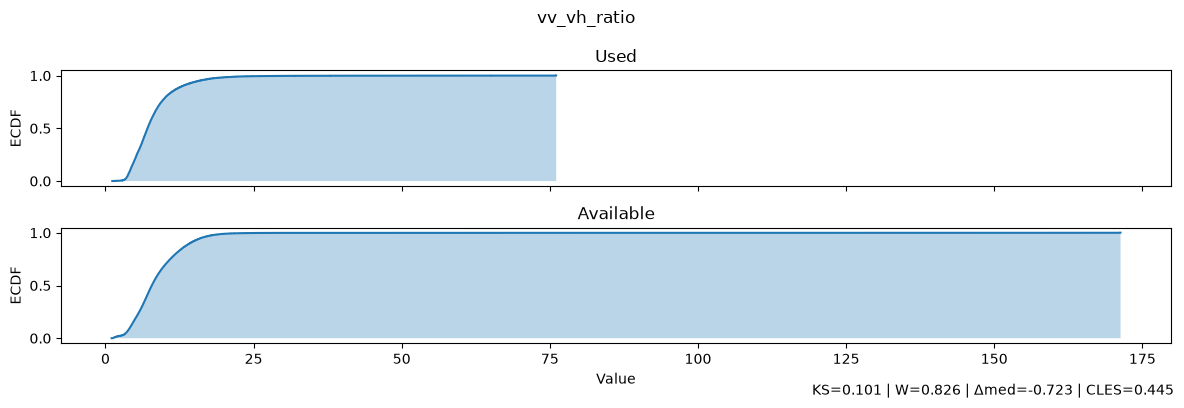

In [67]:
# -------------------------
# Visual Inspection
# -------------------------

from hsa.diagnostics import inspect_sampled_use_available
res = inspect_sampled_use_available(sampled, plot = True)

In [ ]:
# -------------------------
# Model comparison via AIC
# -------------------------
from hsa.rsf import compare_single_predictors, evaluate_linear_candidates_up_to_k
lk = compare_single_predictors(sampled)

In [6]:
# -------------------------
# Fitting a ML-Model
# -------------------------
from hsa.features import FeatureSpec
from hsa.rsf import fit_rsf

#specs = FeatureSpec(linear = ["slope", "ndvi", "distance_to_river_m"], quadratic = ["distance_to_river_m"])
specs = FeatureSpec(linear = ["ndvi", "slope", "distance_to_river_m", "vv_vh_ratio"], quadratic = ["distance_to_river_m"], interactions = [("ndvi", "slope")])
model, scaler, spec, meta = fit_rsf(sampled, specs)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   used   No. Observations:              3510243
Model:                          Logit   Df Residuals:                  3510236
Method:                           MLE   Df Model:                            6
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                 0.09569
Time:                        08:34:30   Log-Likelihood:            -9.7112e+05
converged:                       True   LL-Null:                   -1.0739e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.8262      0.003   -900.958      0.000      -2.832      -2.820
ndvi                        0.4682      0.002    188.677      0.000       0.463       0.473
slope                      -0.4646      0.003   -159.762      0.000      -0.470      -0.459
distance_to_river_m        -0.5182      0.002   -238.082      0.000      -0.522      -0.514
vv_vh_ratio                 0.0620      0.002     28.205      0.000       0.058       0.066
distance_to_river_m__sq     0.2830      0.002    161.363      0.000       0.280       0.286
ndvi__x__slope             -0.0709      0.003    -23.710      0.000      -0.077      -0.065
===========================================================================================
"""

/home/molzoo/miniforge3/envs/hsa/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in exp
  return self.func(*new_argspec)


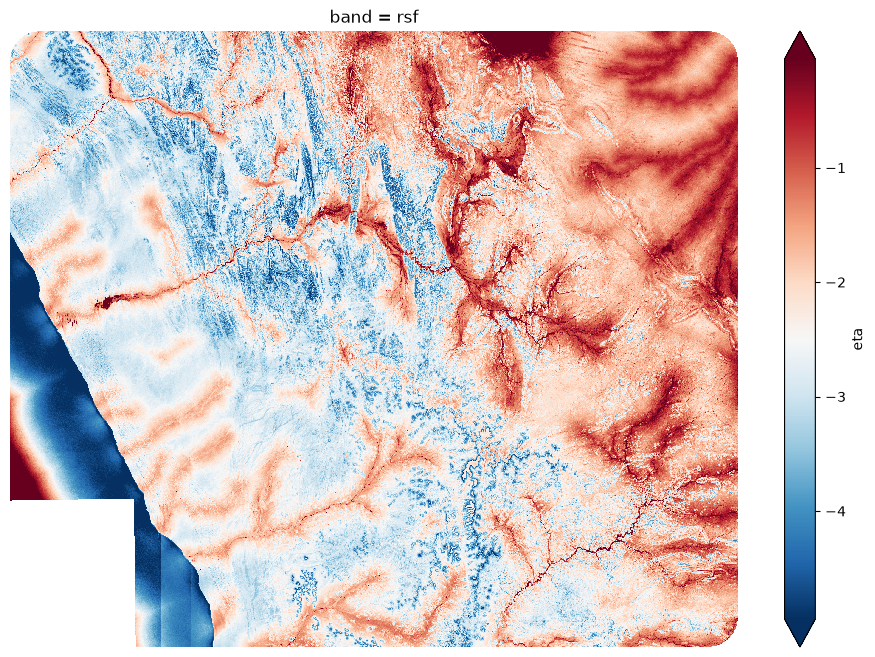

In [7]:
import numpy as np
from hsa.rsf import predict_rsf_surface

rsf = predict_rsf_surface(env, model, scaler, spec, meta)
rsf["exp"] = np.exp(rsf)

eta = np.log(rsf).rename("eta")

q_low, q_high = eta.quantile([0.01, 0.99]).values

fig, ax = plt.subplots(figsize=(12, 8))

eta.plot(
    ax=ax,
    vmin=float(q_low),
    vmax=float(q_high),
    cmap="RdBu_r",
    center=0,
    robust=False,
)

ax.set_aspect("equal")
ax.set_axis_off()
plt.show()

In [63]:
reloc["ID"].unique()

<ArrowStringArray>
[ 'NPL27',  'NPL28',  'NPL32',  'NPL33',  'NPL34',  'NPL35',  'NPL36',
  'NPL37',  'NPL38',  'NPL39',  'NPL40',  'NPL42',  'XPL10', 'XPL103',
 'XPL105', 'XPL106', 'XPL107', 'XPL108', 'XPL109', 'XPL137', 'XPL138',
  'XPL44',  'XPL47',  'XPL73']
Length: 24, dtype: str

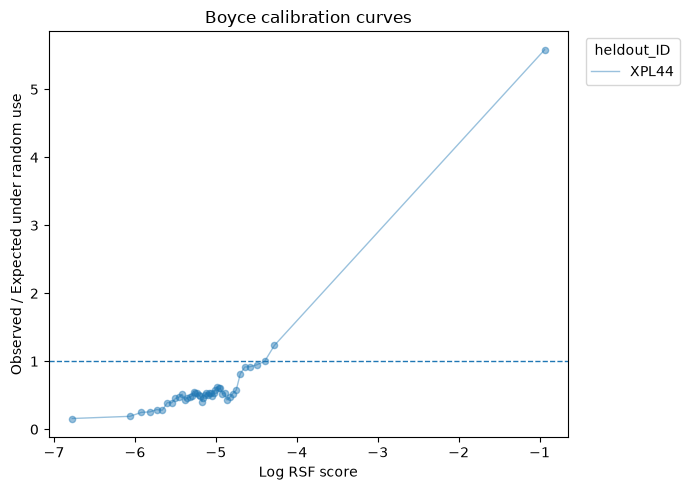

In [58]:
from hsa.rsf.cv import leave_one_individual_out_rsf
from hsa.rsf.validation import plot_boyce_curves

summary, params, boyce_bins, calibration_bins, diagnostics = (
    leave_one_individual_out_rsf(
        reloc,
        env,
        specs,
        id_col="ID",
        heldout = ["XPL44"],
        sampling_factor_train=100,
        n_background_boyce=100_000,
        calibration_n_background=100_000,
        calibration_n_bins=10,
        seed=42,
        #n_bins = 10
    )
)

plot_boyce_curves(boyce_bins)
plt.show()

In [8]:
client.close()

### Bayesian

In [6]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Mapping, Sequence

import numpy as np
import pandas as pd


@dataclass
class BinnedRSFData:
    """
    Container for an aggregated used-available dataset.

    Attributes
    ----------
    data
        Aggregated dataframe containing the mean predictor values,
        used counts, and total trial counts for each joint bin.
    predictors
        Predictor names in model order.
    means
        Means calculated from the original, unrounded observations.
    standard_deviations
        Population standard deviations calculated from the original,
        unrounded observations.
    bin_widths
        Bin width used for each predictor.
    n_original
        Number of complete observations before aggregation.
    n_binned
        Number of joint predictor bins after aggregation.
    """

    data: pd.DataFrame
    predictors: list[str]
    means: pd.Series
    standard_deviations: pd.Series
    bin_widths: dict[str, float]
    n_original: int
    n_binned: int

    @property
    def compression_factor(self) -> float:
        return self.n_original / self.n_binned

    def design_matrix(self, standardize: bool = True) -> np.ndarray:
        """
        Return the predictor matrix in the original predictor order.
        """
        X = self.data[self.predictors].to_numpy(dtype=np.float64)

        if standardize:
            X = (
                X
                - self.means[self.predictors].to_numpy(dtype=np.float64)
            ) / self.standard_deviations[
                self.predictors
            ].to_numpy(dtype=np.float64)

        return X

    @property
    def used_count(self) -> np.ndarray:
        return self.data["used_count"].to_numpy(dtype=np.int64)

    @property
    def n_trials(self) -> np.ndarray:
        return self.data["n_trials"].to_numpy(dtype=np.int64)

def prepare_binned_rsf_data(
    data: pd.DataFrame,
    predictors: Sequence[str],
    *,
    response: str = "used",
    bin_widths: float | Mapping[str, float] = 0.01,
    sort_bins: bool = True,
    verbose: bool = True,
) -> BinnedRSFData:
    """
    Prepare a jointly binned dataset for a pooled Binomial RSF.

    Parameters
    ----------
    data
        Original used-available dataframe.

    predictors
        Continuous predictors to retain, for example:

            ["ndvi", "slope", "distance_to_river_m"]

    response
        Name of the binary used-available response column.

    bin_widths
        Either:

        - one positive number applied to every predictor; or
        - a mapping from predictor names to predictor-specific widths.

        Example:

            {
                "ndvi": 0.01,
                "slope": 0.5,
                "distance_to_river_m": 25.0,
            }

    sort_bins
        Whether pandas should sort the joint bins.

    verbose
        Print the number of original and aggregated observations.

    Returns
    -------
    BinnedRSFData
        Aggregated data and associated scaling metadata.
    """
    predictors = list(predictors)

    if not predictors:
        raise ValueError("At least one predictor must be supplied.")

    if len(set(predictors)) != len(predictors):
        raise ValueError("Predictor names must be unique.")

    required_columns = [response, *predictors]
    missing_columns = [
        column
        for column in required_columns
        if column not in data.columns
    ]

    if missing_columns:
        raise KeyError(
            "The following required columns are missing: "
            + ", ".join(missing_columns)
        )

    # Resolve a common width or predictor-specific widths.
    if np.isscalar(bin_widths):
        width = float(bin_widths)

        if not np.isfinite(width) or width <= 0:
            raise ValueError(
                "`bin_widths` must contain positive finite values."
            )

        widths = {
            predictor: width
            for predictor in predictors
        }

    else:
        widths = {}

        missing_widths = [
            predictor
            for predictor in predictors
            if predictor not in bin_widths
        ]

        if missing_widths:
            raise KeyError(
                "No bin width was supplied for: "
                + ", ".join(missing_widths)
            )

        for predictor in predictors:
            width = float(bin_widths[predictor])

            if not np.isfinite(width) or width <= 0:
                raise ValueError(
                    f"Invalid bin width for {predictor!r}: {width}"
                )

            widths[predictor] = width

    # Retain complete and finite observations only.
    d = (
        data[required_columns]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    if d.empty:
        raise ValueError(
            "No complete finite observations remain after filtering."
        )

    # Validate the binary response.
    response_values = set(pd.unique(d[response]))

    if not response_values.issubset({0, 1, False, True}):
        raise ValueError(
            f"`{response}` must be binary and coded as 0/1."
        )

    d[response] = d[response].astype(np.int8)

    # Scaling parameters must be calculated from the original,
    # unrounded observations.
    means = d[predictors].mean()
    standard_deviations = d[predictors].std(ddof=0)

    invalid_sd = (
        ~np.isfinite(standard_deviations)
        | (standard_deviations <= 0)
    )

    if invalid_sd.any():
        invalid_predictors = standard_deviations.index[
            invalid_sd
        ].tolist()

        raise ValueError(
            "The following predictors have zero or invalid variance: "
            + ", ".join(invalid_predictors)
        )

    # Create temporary bin identifiers.
    bin_columns = []

    for predictor in predictors:
        bin_column = f"__bin_{predictor}"
        width = widths[predictor]

        d[bin_column] = np.rint(
            d[predictor].to_numpy(dtype=np.float64) / width
        ).astype(np.int64)

        bin_columns.append(bin_column)

    # Construct named aggregations programmatically.
    aggregations = {
        predictor: (predictor, "mean")
        for predictor in predictors
    }

    aggregations.update(
        {
            "used_count": (response, "sum"),
            "n_trials": (response, "size"),
        }
    )

    binned = (
        d.groupby(
            bin_columns,
            sort=sort_bins,
            observed=True,
        )
        .agg(**aggregations)
        .reset_index(drop=True)
    )

    result = BinnedRSFData(
        data=binned,
        predictors=predictors,
        means=means,
        standard_deviations=standard_deviations,
        bin_widths=widths,
        n_original=len(d),
        n_binned=len(binned),
    )

    if verbose:
        print(f"Predictors:            {', '.join(predictors)}")
        print(f"Original observations: {result.n_original:,}")
        print(f"Joint bins:            {result.n_binned:,}")
        print(
            f"Compression factor:    "
            f"{result.compression_factor:,.1f}×"
        )

        print("\nBin widths:")

        for predictor, width in widths.items():
            print(f"  {predictor:<25} {width:g}")

    return result

prepared = prepare_binned_rsf_data(
    sampled,
    predictors=["ndvi", "slope"],
    bin_widths=0.01,
)

Predictors:            ndvi, slope
Original observations: 3,510,243
Joint bins:            48,593
Compression factor:    72.2×

Bin widths:
  ndvi                      0.01
  slope                     0.01


In [28]:
import pymc as pm
def build_binned_rsf_model(
    prepared: BinnedRSFData,
    *,
    prior_beta_sd: float = 1.0,
    prior_alpha_sd: float = 2.5,
) -> pm.Model:
    """
    Build a pooled Bayesian RSF using an aggregated Binomial likelihood.

    Predictor coefficients apply to standardized predictors.
    """
    if prior_beta_sd <= 0:
        raise ValueError("`prior_beta_sd` must be positive.")

    if prior_alpha_sd <= 0:
        raise ValueError("`prior_alpha_sd` must be positive.")

    X = prepared.design_matrix(standardize=True)
    k_used = prepared.used_count
    n_trials = prepared.n_trials

    overall_used_fraction = (
        k_used.sum() / n_trials.sum()
    )

    overall_used_fraction = np.clip(
        overall_used_fraction,
        1e-9,
        1 - 1e-9,
    )

    alpha_location = np.log(
        overall_used_fraction
        / (1 - overall_used_fraction)
    )

    coords = {
        "bin": np.arange(prepared.n_binned),
        "predictor": prepared.predictors,
    }

    with pm.Model(coords=coords) as model:

        X_data = pm.Data(
            "X",
            X,
            dims=("bin", "predictor"),
        )

        trials = pm.Data(
            "n_trials",
            n_trials,
            dims="bin",
        )

        alpha = pm.Normal(
            "alpha",
            mu=alpha_location,
            sigma=prior_alpha_sd,
        )

        beta = pm.Normal(
            "beta",
            mu=0.0,
            sigma=prior_beta_sd,
            dims="predictor",
        )

        eta = alpha + pm.math.dot(X_data, beta)

        pm.Binomial(
            "used_count",
            n=trials,
            logit_p=eta,
            observed=k_used,
            dims="bin",
        )

    return model

In [29]:
model = build_binned_rsf_model(prepared)

with model:
    idata = pm.sample(
        draws=1_000,
        tune=1_000,
        chains=4,
        cores=4,
        nuts_sampler="nutpie",
        nuts={"target_accept": 0.90},
        random_seed=42,
    )

NUTS[nutpie]: [alpha, beta]


Output()

In [ ]:
import arviz as az
az.summary(
    idata,
    var_names=["alpha", "beta"],
    ci_kind="eti",
    ci_prob=0.95,
    round_to=4,
)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-2.4886,0.0022,-2.4928,-2.4844,2786.2831,2722.3175,1.0008,0.0000,0.0
beta[ndvi],0.5591,0.0018,0.5554,0.5627,3282.6514,2907.2235,1.0009,0.0000,0.0
beta[slope],-0.5448,0.0027,-0.5501,-0.5394,2989.3465,3179.8709,1.0004,0.0001,0.0


In [31]:
rss_1sd = np.exp(
    idata.posterior["beta"]
).rename("rss_1sd")

rss_summary = az.summary(
    rss_1sd,
    ci_kind="eti",
    ci_prob=0.95,
    round_to=4,
)

rss_summary

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
rss_1sd[ndvi],1.7491,0.0032,1.7426,1.7555,3282.6514,2907.2235,1.0009,0.0001,0.0
rss_1sd[slope],0.5800,0.0016,0.5769,0.5831,2989.3465,3179.8709,1.0004,0.0000,0.0


In [32]:
prepared.compression_factor

72.23762681867758

### Hierarchical Model

In [7]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Mapping, Sequence

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

In [8]:
@dataclass
class HierarchicalBinnedRSFData:
    """
    Jointly binned used-available data for a hierarchical RSF.

    Attributes
    ----------
    data
        Aggregated dataframe. Each row represents one joint predictor
        bin within one grouping unit.
    predictors
        Predictor names in model order.
    group_column
        Name of the grouping variable, such as "individual_id".
    groups
        Original group labels in model-coordinate order.
    means
        Predictor means from the complete, unrounded source data.
    standard_deviations
        Predictor population standard deviations from the complete,
        unrounded source data.
    bin_widths
        Width used for each predictor.
    n_original
        Number of complete source observations.
    n_binned
        Number of aggregated group-by-bin observations.
    """

    data: pd.DataFrame
    predictors: list[str]
    group_column: str
    groups: list
    means: pd.Series
    standard_deviations: pd.Series
    bin_widths: dict[str, float]
    n_original: int
    n_binned: int

    @property
    def n_groups(self) -> int:
        return len(self.groups)

    @property
    def compression_factor(self) -> float:
        return self.n_original / self.n_binned

    def design_matrix(
        self,
        standardize: bool = True,
    ) -> np.ndarray:
        X = self.data[self.predictors].to_numpy(
            dtype=np.float64
        )

        if standardize:
            means = self.means[
                self.predictors
            ].to_numpy(dtype=np.float64)

            sds = self.standard_deviations[
                self.predictors
            ].to_numpy(dtype=np.float64)

            X = (X - means) / sds

        return X

    @property
    def group_index(self) -> np.ndarray:
        return self.data["group_index"].to_numpy(
            dtype=np.int64
        )

    @property
    def used_count(self) -> np.ndarray:
        return self.data["used_count"].to_numpy(
            dtype=np.int64
        )

    @property
    def n_trials(self) -> np.ndarray:
        return self.data["n_trials"].to_numpy(
            dtype=np.int64
        )

In [9]:
def prepare_hierarchical_binned_rsf_data(
    data: pd.DataFrame,
    predictors: Sequence[str],
    group: str,
    *,
    response: str = "used",
    bin_widths: float | Mapping[str, float] = 0.01,
    sort_bins: bool = True,
    min_observations_per_group: int = 1,
    verbose: bool = True,
) -> HierarchicalBinnedRSFData:
    """
    Prepare jointly binned data for a hierarchical Binomial RSF.

    Parameters
    ----------
    data
        Original used-available dataframe.

    predictors
        Continuous predictors included in the model.

    group
        Column defining the hierarchical unit, such as individual ID,
        deployment ID, season, or study area.

    response
        Binary used-available response column.

    bin_widths
        Either one common positive width or a mapping containing one
        width per predictor.

    sort_bins
        Whether joint predictor bins should be sorted.

    min_observations_per_group
        Groups with fewer complete observations than this are removed.

    verbose
        Print a preparation summary.

    Returns
    -------
    HierarchicalBinnedRSFData
        Aggregated data and associated model metadata.
    """
    predictors = list(predictors)

    if not predictors:
        raise ValueError(
            "At least one predictor must be supplied."
        )

    if len(set(predictors)) != len(predictors):
        raise ValueError(
            "Predictor names must be unique."
        )

    if group in predictors:
        raise ValueError(
            "The grouping column cannot also be a predictor."
        )

    required_columns = [
        response,
        group,
        *predictors,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in data.columns
    ]

    if missing_columns:
        raise KeyError(
            "Missing required columns: "
            + ", ".join(missing_columns)
        )

    # Resolve bin widths.
    if np.isscalar(bin_widths):
        width = float(bin_widths)

        if not np.isfinite(width) or width <= 0:
            raise ValueError(
                "`bin_widths` must be positive and finite."
            )

        widths = {
            predictor: width
            for predictor in predictors
        }

    else:
        missing_widths = [
            predictor
            for predictor in predictors
            if predictor not in bin_widths
        ]

        if missing_widths:
            raise KeyError(
                "No bin width supplied for: "
                + ", ".join(missing_widths)
            )

        widths = {}

        for predictor in predictors:
            width = float(bin_widths[predictor])

            if not np.isfinite(width) or width <= 0:
                raise ValueError(
                    f"Invalid width for {predictor!r}: "
                    f"{width}"
                )

            widths[predictor] = width

    # Keep complete finite observations.
    d = (
        data[required_columns]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    if d.empty:
        raise ValueError(
            "No complete finite observations remain."
        )

    response_values = set(pd.unique(d[response]))

    if not response_values.issubset(
        {0, 1, False, True}
    ):
        raise ValueError(
            f"`{response}` must be binary and coded 0/1."
        )

    d[response] = d[response].astype(np.int8)

    # Remove groups with too little information.
    group_sizes = d.groupby(group).size()

    retained_groups = group_sizes[
        group_sizes >= min_observations_per_group
    ].index

    d = d[d[group].isin(retained_groups)].copy()

    if d.empty:
        raise ValueError(
            "No groups remain after applying "
            "`min_observations_per_group`."
        )

    # Global scaling preserves direct comparability among individuals.
    means = d[predictors].mean()
    standard_deviations = d[predictors].std(ddof=0)

    invalid_sd = (
        ~np.isfinite(standard_deviations)
        | (standard_deviations <= 0)
    )

    if invalid_sd.any():
        invalid_predictors = standard_deviations.index[
            invalid_sd
        ].tolist()

        raise ValueError(
            "Zero or invalid variance for: "
            + ", ".join(invalid_predictors)
        )

    # Stable group codes.
    group_codes, group_labels = pd.factorize(
        d[group],
        sort=True,
    )

    d["group_index"] = group_codes.astype(np.int64)

    group_lookup = (
        d[[group, "group_index"]]
        .drop_duplicates()
        .set_index("group_index")[group]
        .sort_index()
    )

    groups = group_lookup.tolist()

    # Integer predictor-bin identifiers avoid floating-point
    # grouping problems.
    bin_columns = []

    for predictor in predictors:
        bin_column = f"__bin_{predictor}"

        d[bin_column] = np.rint(
            d[predictor].to_numpy(dtype=np.float64)
            / widths[predictor]
        ).astype(np.int64)

        bin_columns.append(bin_column)

    aggregations = {
        predictor: (predictor, "mean")
        for predictor in predictors
    }

    aggregations.update(
        {
            "used_count": (response, "sum"),
            "n_trials": (response, "size"),
        }
    )

    binned = (
        d.groupby(
            ["group_index", *bin_columns],
            sort=sort_bins,
            observed=True,
        )
        .agg(**aggregations)
        .reset_index()
    )

    # Restore human-readable group labels.
    binned[group] = binned["group_index"].map(
        group_lookup
    )

    result = HierarchicalBinnedRSFData(
        data=binned,
        predictors=predictors,
        group_column=group,
        groups=groups,
        means=means,
        standard_deviations=standard_deviations,
        bin_widths=widths,
        n_original=len(d),
        n_binned=len(binned),
    )

    if verbose:
        print(
            f"Predictors:            "
            f"{', '.join(predictors)}"
        )
        print(f"Grouping variable:     {group}")
        print(
            f"Groups retained:       "
            f"{result.n_groups:,}"
        )
        print(
            f"Original observations: "
            f"{result.n_original:,}"
        )
        print(
            f"Group-specific bins:   "
            f"{result.n_binned:,}"
        )
        print(
            f"Compression factor:    "
            f"{result.compression_factor:,.1f}×"
        )

        print("\nBin widths:")

        for predictor, width in widths.items():
            print(f"  {predictor:<28} {width:g}")

    return result

In [10]:
def build_hierarchical_binned_rsf_model(
    prepared: HierarchicalBinnedRSFData,
    *,
    varying_intercept: bool = True,
    varying_slopes: Sequence[str] | None = None,
    prior_beta_sd: float = 1.0,
    prior_alpha_sd: float = 2.5,
    prior_group_sd: float = 0.5,
) -> pm.Model:
    """
    Build a hierarchical Bayesian RSF with an aggregated
    Binomial likelihood.

    Parameters
    ----------
    prepared
        Output from `prepare_hierarchical_binned_rsf_data`.

    varying_intercept
        Whether the intercept varies among groups.

    varying_slopes
        Predictor names whose coefficients vary among groups.
        Predictors omitted from this argument retain pooled slopes.

        Examples
        --------
        Varying intercept only:

            varying_slopes=[]

        Varying NDVI slope:

            varying_slopes=["ndvi"]

        All slopes varying:

            varying_slopes=prepared.predictors

    prior_beta_sd
        Standard deviation of population-level coefficient priors.

    prior_alpha_sd
        Standard deviation of the population intercept prior.

    prior_group_sd
        Scale of the HalfNormal priors placed on among-group
        standard deviations.

    Returns
    -------
    pm.Model
        A compiled PyMC model.
    """
    predictors = prepared.predictors

    if varying_slopes is None:
        varying_slopes = []

    varying_slopes = list(varying_slopes)

    unknown_slopes = [
        predictor
        for predictor in varying_slopes
        if predictor not in predictors
    ]

    if unknown_slopes:
        raise ValueError(
            "Unknown varying slopes: "
            + ", ".join(unknown_slopes)
        )

    if len(set(varying_slopes)) != len(varying_slopes):
        raise ValueError(
            "`varying_slopes` contains duplicates."
        )

    if prior_beta_sd <= 0:
        raise ValueError(
            "`prior_beta_sd` must be positive."
        )

    if prior_alpha_sd <= 0:
        raise ValueError(
            "`prior_alpha_sd` must be positive."
        )

    if prior_group_sd <= 0:
        raise ValueError(
            "`prior_group_sd` must be positive."
        )

    X = prepared.design_matrix(standardize=True)
    group_index = prepared.group_index
    k_used = prepared.used_count
    n_trials = prepared.n_trials

    used_fraction = (
        k_used.sum() / n_trials.sum()
    )

    used_fraction = np.clip(
        used_fraction,
        1e-9,
        1 - 1e-9,
    )

    alpha_location = np.log(
        used_fraction / (1 - used_fraction)
    )

    varying_indices = np.array(
        [
            predictors.index(predictor)
            for predictor in varying_slopes
        ],
        dtype=np.int64,
    )

    fixed_slopes = [
        predictor
        for predictor in predictors
        if predictor not in varying_slopes
    ]

    fixed_indices = np.array(
        [
            predictors.index(predictor)
            for predictor in fixed_slopes
        ],
        dtype=np.int64,
    )

    coords = {
        "bin": np.arange(prepared.n_binned),
        "predictor": predictors,
        "group": prepared.groups,
    }

    if varying_slopes:
        coords["varying_predictor"] = varying_slopes

    if fixed_slopes:
        coords["fixed_predictor"] = fixed_slopes

    with pm.Model(coords=coords) as model:

        X_data = pm.Data(
            "X",
            X,
            dims=("bin", "predictor"),
        )

        group_idx = pm.Data(
            "group_index",
            group_index,
            dims="bin",
        )

        trials = pm.Data(
            "n_trials",
            n_trials,
            dims="bin",
        )

        # ------------------------------------
        # Population intercept
        # ------------------------------------
        mu_alpha = pm.Normal(
            "mu_alpha",
            mu=alpha_location,
            sigma=prior_alpha_sd,
        )

        if varying_intercept:
            sigma_alpha = pm.HalfNormal(
                "sigma_alpha",
                sigma=prior_group_sd,
            )

            z_alpha = pm.Normal(
                "z_alpha",
                mu=0.0,
                sigma=1.0,
                dims="group",
            )

            alpha_group = pm.Deterministic(
                "alpha_group",
                mu_alpha + sigma_alpha * z_alpha,
                dims="group",
            )

            alpha_bin = alpha_group[group_idx]

        else:
            alpha_bin = mu_alpha

        # ------------------------------------
        # Population-level slopes
        # ------------------------------------
        mu_beta = pm.Normal(
            "mu_beta",
            mu=0.0,
            sigma=prior_beta_sd,
            dims="predictor",
        )

        eta = alpha_bin

        # Pooled coefficients.
        if fixed_slopes:
            eta = eta + pm.math.dot(
                X_data[:, fixed_indices],
                mu_beta[fixed_indices],
            )

        # Group-specific coefficients.
        if varying_slopes:
            sigma_beta = pm.HalfNormal(
                "sigma_beta",
                sigma=prior_group_sd,
                dims="varying_predictor",
            )

            z_beta = pm.Normal(
                "z_beta",
                mu=0.0,
                sigma=1.0,
                dims=("group", "varying_predictor"),
            )

            beta_group = pm.Deterministic(
                "beta_group",
                (
                    mu_beta[varying_indices][None, :]
                    + z_beta * sigma_beta[None, :]
                ),
                dims=("group", "varying_predictor"),
            )

            X_varying = X_data[:, varying_indices]

            eta = eta + pm.math.sum(
                X_varying * beta_group[group_idx],
                axis=1,
            )

        pm.Binomial(
            "used_count",
            n=trials,
            logit_p=eta,
            observed=k_used,
            dims="bin",
        )

    return model

In [15]:
hierarchical_data = prepare_hierarchical_binned_rsf_data(
    sampled,
    predictors=[
        "ndvi",
        "slope",
    ],
    group="ID",  
    bin_widths={
        "ndvi": 0.1,
        "slope": 1,
    },
    min_observations_per_group=100,
)

Predictors:            ndvi, slope
Grouping variable:     ID
Groups retained:       24
Original observations: 3,510,243
Group-specific bins:   2,999
Compression factor:    1,170.5×

Bin widths:
  ndvi                         0.1
  slope                        1


In [16]:
hierarchical_model = build_hierarchical_binned_rsf_model(
    hierarchical_data,
    varying_intercept=True,
    varying_slopes=["ndvi"],
    prior_beta_sd=1.0,
    prior_alpha_sd=2.5,
    prior_group_sd=0.5,
)

In [17]:
with hierarchical_model:
    idata_hierarchical = pm.sample(
        draws=1_000,
        tune=1_500,
        chains=4,
        cores=4,
        nuts_sampler="nutpie",
        nuts={"target_accept": 0.90},
        random_seed=42,
    )

NUTS[nutpie]: [mu_alpha, sigma_alpha, z_alpha, mu_beta, sigma_beta, z_beta]


Output()